<a href="https://colab.research.google.com/github/broistg/ML-Assignment-DNAC1/blob/experiment/notebooks/BTL_Ext_HMM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Preparation

In [8]:
import os
import subprocess

# Replace with your GitHub repository URL
repo_url = "https://github.com/broistg/ML-Assignment-DNAC1.git"
repo_dir = "ML-Assignment-DNAC1" # Replace with your repository name

# Clone the repository if it doesn't exist
if not os.path.exists(repo_dir):
    print(f"Cloning repository: {repo_url}")
    subprocess.run(["git", "clone", repo_url])
else:
    print(f"Repository already exists: {repo_dir}")

# Define the path where features are expected to be
features_dir_in_repo = os.path.join(repo_dir, "features/timit") # Assuming features are in a 'timit_features' directory within the repo
mfcc_filepath_in_repo = os.path.join(features_dir_in_repo, "mfcc_concat.npy")
sequences_filepath_in_repo = os.path.join(features_dir_in_repo, "all_sequences.pkl")

# Check if features exist in the cloned repository
features_exist = os.path.exists(mfcc_filepath_in_repo) and os.path.exists(sequences_filepath_in_repo)

if features_exist:
    print("Feature files found in the repository.")
    # You can add code here to load the features if needed in this cell
    # For now, we will just set a flag for the next cell to use
    load_features_from_repo = True
else:
    print("Feature files not found in the repository. Feature extraction will proceed.")
    load_features_from_repo = False

Repository already exists: ML-Assignment-DNAC1
Feature files not found in the repository. Feature extraction will proceed.


In [9]:
import kagglehub

# Download latest version
timit_dir = kagglehub.dataset_download("mfekadu/darpa-timit-acousticphonetic-continuous-speech")

print("Path to dataset files:", timit_dir)

Using Colab cache for faster access to the 'darpa-timit-acousticphonetic-continuous-speech' dataset.
Path to dataset files: /kaggle/input/darpa-timit-acousticphonetic-continuous-speech


In [12]:
import os

# Collect MFCCs from training set
timit_wav_files = []
# You will need to ensure the TIMIT dataset is in the './TIMIT' directory
# before running the rest of the code.
if os.path.exists(timit_dir):
    for root, dirs, files in os.walk(timit_dir):
        for file in files:
            if file.endswith('.wav'):
                timit_wav_files.append(os.path.join(root, file))

    print(f"Found {len(timit_wav_files)} WAV files in TIMIT directory.")
else:
    print(f"TIMIT directory not found at {timit_dir} after attempted download/extraction.")
    print("Please ensure the dataset is downloaded and extracted to this location manually.")

Found 6300 WAV files in TIMIT directory.


EDA

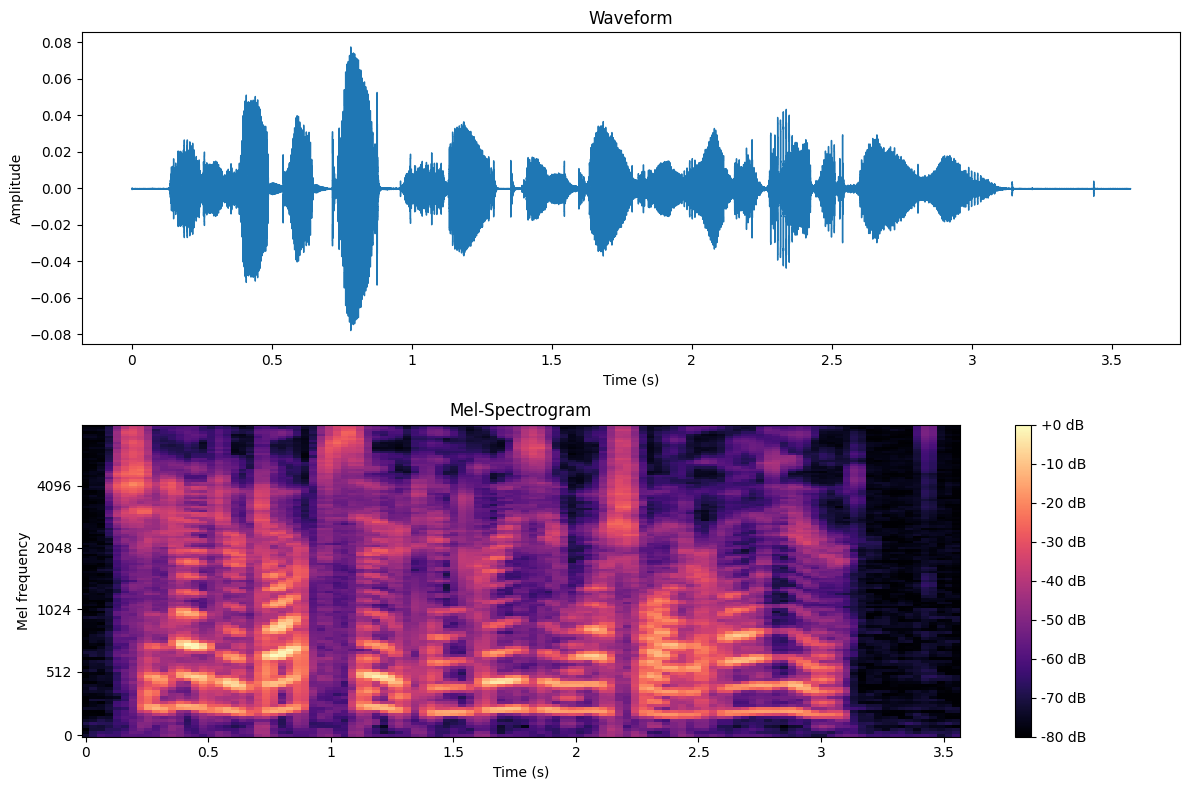

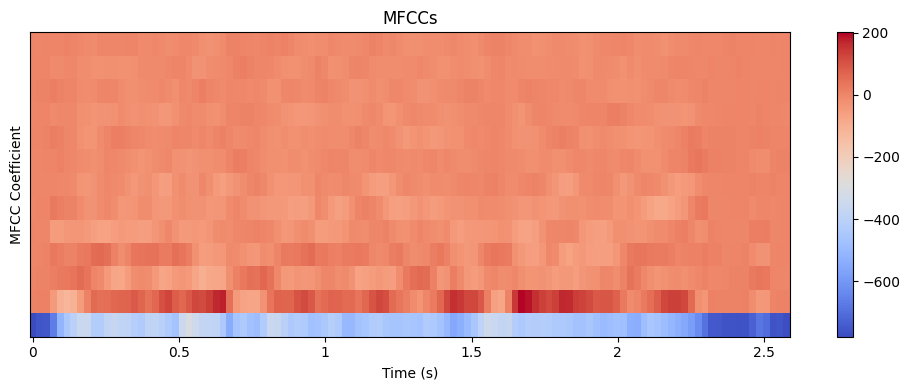

In [13]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import numpy as np
import os

# Function to load audio and extract MFCCs (reusing the function defined earlier)
def load_timit_audio(path):
    y, sr = librosa.load(path, sr=16000)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13).T
    return mfcc

# --- EDA ---

# Analyze the distribution of file lengths
file_lengths = []
for wav_file in timit_wav_files:
    try:
        y, sr = librosa.load(wav_file, sr=16000)
        file_lengths.append(len(y) / sr)  # length in seconds
    except Exception as e:
        print(f"Error loading {wav_file}: {e}")

fig1 = go.Figure(data=[go.Histogram(x=file_lengths, nbinsx=50)])
fig1.update_layout(title="Distribution of Audio File Lengths",
                   xaxis_title="Length (seconds)",
                   yaxis_title="Count")
fig1.show()

# Analyze the distribution of MFCC features (example for one file)
if timit_wav_files:
    example_mfcc = load_timit_audio(timit_wav_files[0])

    fig2 = go.Figure(data=[go.Box(y=example_mfcc[:, i], name=f'MFCC {i+1}') for i in range(example_mfcc.shape[1])])
    fig2.update_layout(title="Distribution of MFCC Features (Example File)",
                       xaxis_title="MFCC Index",
                       yaxis_title="Feature Value")
    fig2.show()

# Visualize an example spectrogram and MFCCs
if timit_wav_files:
    example_wav_file = timit_wav_files[0]
    y, sr = librosa.load(example_wav_file, sr=16000)
    example_mfcc = load_timit_audio(example_wav_file)

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 1, 1)
    librosa.display.waveshow(y, sr=sr)
    plt.title('Waveform')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')

    plt.subplot(2, 1, 2)
    librosa.display.specshow(librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=sr), ref=np.max),
                             sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Mel-Spectrogram')
    plt.xlabel('Time (s)')
    plt.ylabel('Mel frequency')

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(example_mfcc.T, x_axis='time')
    plt.colorbar()
    plt.title('MFCCs')
    plt.xlabel('Time (s)')
    plt.ylabel('MFCC Coefficient')
    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.cluster import KMeans
import numpy as np
import os
import librosa
import pickle

# Define the path where features are expected to be saved
output_dir = "./timit_features"
mfcc_filepath = os.path.join(output_dir, "mfcc_concat.npy")
sequences_filepath = os.path.join(output_dir, "all_sequences.pkl")

# Check if features already exist or if they were loaded from the repository
if 'load_features_from_repo' in locals() and load_features_from_repo:
    print("Features were loaded from the repository, skipping extraction.")
    # Load features from the repository path if not already loaded
    repo_dir = "ML-Assignment-DNAC1" # Replace with your repository name
    features_dir_in_repo = os.path.join(repo_dir, "features/timit") # Assuming features are in a 'timit_features' directory within the repo
    mfcc_filepath_in_repo = os.path.join(features_dir_in_repo, "mfcc_concat.npy")
    sequences_filepath_in_repo = os.path.join(features_dir_in_repo, "all_sequences.pkl")

    try:
        mfcc_concat = np.load(mfcc_filepath_in_repo)
        with open(sequences_filepath_in_repo, 'rb') as f:
            all_sequences = pickle.load(f)
        print("Features loaded from repository successfully.")
    except FileNotFoundError:
        print("Error loading features from repository. Proceeding with extraction.")
        load_features_from_repo = False # Reset flag to proceed with extraction
    except Exception as e:
        print(f"An error occurred while loading features from repository: {e}. Proceeding with extraction.")
        load_features_from_repo = False # Reset flag to proceed with extraction


if not ('load_features_from_repo' in locals() and load_features_from_repo):
    print("Feature files not found or loading from repository failed. Extracting and clustering features...")
    def load_timit_audio(path):
        y, sr = librosa.load(path, sr=16000)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13).T
        return mfcc

    all_mfccs = []
    all_sequences = []
    for wav in timit_wav_files:
        mfcc = load_timit_audio(wav)
        all_mfccs.append(mfcc)

    # cluster MFCCs into discrete "codebook"
    mfcc_concat = np.vstack(all_mfccs)
    kmeans = KMeans(n_clusters=64, random_state=42, n_init=10).fit(mfcc_concat)
    all_sequences = [kmeans.predict(mfcc) for mfcc in all_mfccs]

    # Save the extracted features
    os.makedirs(output_dir, exist_ok=True)
    np.save(mfcc_filepath, mfcc_concat)
    with open(sequences_filepath, 'wb') as f:
        pickle.dump(all_sequences, f)
    print(f"Saved concatenated MFCC features to: {mfcc_filepath}")
    print(f"Saved clustered sequences to: {sequences_filepath}")

Saving features and sequences

In [ ]:
import os
import pickle

# Check if features were loaded from the repository
if 'load_features_from_repo' not in locals() or not load_features_from_repo:
    print("Features were not loaded from the repository. Saving extracted features...")
    # Create a directory to save the features and sequences
    output_dir = "./timit_features"
    os.makedirs(output_dir, exist_ok=True)

    # Save concatenated MFCC features
    mfcc_filepath = os.path.join(output_dir, "mfcc_concat.npy")
    np.save(mfcc_filepath, mfcc_concat)
    print(f"Saved concatenated MFCC features to: {mfcc_filepath}")

    # Save clustered sequences
    sequences_filepath = os.path.join(output_dir, "all_sequences.pkl")
    with open(sequences_filepath, 'wb') as f:
        pickle.dump(all_sequences, f)
    print(f"Saved clustered sequences to: {sequences_filepath}")

    print("\nYou can download the files from the 'timit_features' directory and upload them to your GitHub repository.")
else:
    print("Features were loaded from the repository. Skipping saving.")

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Assuming 'all_sequences' contains your processed data sequences
# and you have corresponding labels if needed for supervised learning.
# For unsupervised learning (like basic HMM training without labels),
# you might just split the sequences.
# If you have corresponding labels for each sequence, include them in the split.

# For this example, let's assume we are splitting the sequences themselves.
# If you have labels (e.g., phoneme sequences), include them like:
# train_sequences, test_sequences, train_labels, test_labels = train_test_split(all_sequences, all_labels, test_size=0.2, random_state=42)

train_sequences, test_sequences = train_test_split(all_sequences, test_size=0.2, random_state=42)

print(f"Number of training sequences: {len(train_sequences)}")
print(f"Number of testing sequences: {len(test_sequences)}")

Core Implementation

In [ ]:
import numpy as np

class HMM:
    def __init__(self, n_states, n_obs):
        self.n_states = n_states
        self.n_obs = n_obs

        # Initialize params randomly
        self.A = np.ones((n_states, n_states)) / n_states  # transition
        self.B = np.ones((n_states, n_obs)) / n_obs        # emission (discrete for now)
        self.pi = np.ones(n_states) / n_states             # initial state prob

    # Forward algorithm
    def forward(self, obs_seq):
        T = len(obs_seq)
        alpha = np.zeros((T, self.n_states))

        # init
        alpha[0] = self.pi * self.B[:, obs_seq[0]]

        # recursion
        for t in range(1, T):
            for j in range(self.n_states):
                alpha[t, j] = self.B[j, obs_seq[t]] * np.sum(alpha[t-1] * self.A[:, j])

        return alpha, np.sum(alpha[-1])

    # Viterbi algorithm
    def viterbi(self, obs_seq):
        T = len(obs_seq)
        delta = np.zeros((T, self.n_states))
        psi = np.zeros((T, self.n_states), dtype=int)

        # init
        delta[0] = self.pi * self.B[:, obs_seq[0]]

        # recursion
        for t in range(1, T):
            for j in range(self.n_states):
                prob = delta[t-1] * self.A[:, j]
                psi[t, j] = np.argmax(prob)
                delta[t, j] = np.max(prob) * self.B[j, obs_seq[t]]

        # backtrack
        states = np.zeros(T, dtype=int)
        states[-1] = np.argmax(delta[-1])
        for t in range(T-2, -1, -1):
            states[t] = psi[t+1, states[t+1]]

        return states, np.max(delta[-1])

    # Baum-Welch (EM)
    def baum_welch(self, sequences, n_iter=10):
        for _ in range(n_iter):
            A_num = np.zeros_like(self.A)
            A_den = np.zeros((self.n_states, 1))
            B_num = np.zeros_like(self.B)
            B_den = np.zeros((self.n_states, 1))
            pi_new = np.zeros_like(self.pi)

            for obs_seq in sequences:
                T = len(obs_seq)
                epsilon = 1e-10  # Small value to prevent division by zero

                # forward-backward
                alpha, prob = self.forward(obs_seq)
                beta = np.zeros((T, self.n_states))
                beta[-1] = 1

                for t in range(T-2, -1, -1):
                    for i in range(self.n_states):
                        beta[t, i] = np.sum(self.A[i] * self.B[:, obs_seq[t+1]] * beta[t+1])

                gamma = (alpha * beta) / (np.sum(alpha[-1]) + epsilon)
                xi = np.zeros((T-1, self.n_states, self.n_states))

                for t in range(T-1):
                    denom = np.sum(alpha[t] * beta[t]) + epsilon
                    for i in range(self.n_states):
                        xi[t, i] = alpha[t, i] * self.A[i] * self.B[:, obs_seq[t+1]] * beta[t+1]
                    xi[t] /= denom

                # accumulate stats
                pi_new += gamma[0]
                A_num += np.sum(xi, axis=0)
                A_den += np.sum(gamma[:-1], axis=0, keepdims=True).T + epsilon
                for t in range(T):
                    B_num[:, obs_seq[t]] += gamma[t]
                B_den += np.sum(gamma, axis=0, keepdims=True).T + epsilon

            # update params
            self.A = A_num / A_den
            self.B = B_num / B_den
            self.pi = pi_new / len(sequences)

Training

In [ ]:
# Train HMM
hmm = HMM(n_states=40, n_obs=64)   # e.g., 40 phonemes, 64 acoustic symbols
hmm.baum_welch(train_sequences, n_iter=20)

Comparison

In [ ]:
import plotly.graph_objs as go
import numpy as np

# === 1. Forward likelihoods ===
log_likelihoods = []
# Ensure test_sequences is defined, assuming it was loaded/split in previous cells
if 'test_sequences' in locals():
    for seq in test_sequences:
        _, prob = hmm.forward(seq)
        # Add epsilon to probability before taking log to avoid log(0)
        log_likelihoods.append(np.log(prob + 1e-12))

    fig1 = go.Figure()
    fig1.add_trace(go.Bar(
        x=list(range(len(test_sequences))),
        y=log_likelihoods,
        name="Log-likelihood"
    ))
    fig1.update_layout(title="Forward Algorithm: Sequence Likelihoods",
                       xaxis_title="Sequence index",
                       yaxis_title="Log-likelihood")
    fig1.show()
else:
    print("Error: test_sequences not found. Please ensure the data splitting cell was executed.")


# === 2. Viterbi decoding ===
# Ensure test_sequences is defined and not empty before attempting Viterbi
if 'test_sequences' in locals() and test_sequences:
    seq = test_sequences[0]
    states, score = hmm.viterbi(seq)

    fig2 = go.Figure()
    fig2.add_trace(go.Scatter(y=states, mode="lines", name="Predicted states"))
    if "ground_truth_states" in locals():  # optional, if you have labels
        fig2.add_trace(go.Scatter(y=ground_truth_states[0], mode="lines", name="True states"))
    fig2.update_layout(title="Viterbi Decoding: State Sequence",
                       xaxis_title="Time step",
                       yaxis_title="State index")
    fig2.show()
else:
     print("Error: test_sequences not found or is empty. Cannot perform Viterbi decoding.")


# === 3. Baum-Welch convergence ===
# This part depends on collecting log-likelihoods during Baum-Welch training.
# You would need to modify the baum_welch method to store these.
# For now, using placeholder data.
# log_likelihoods_em = [ -1234, -980, -890, -860 ]  # track during training

# fig3 = go.Figure()
# fig3.add_trace(go.Scatter(y=log_likelihoods_em, mode="lines+markers", name="Log-likelihood"))
# fig3.update_layout(title="Baum-Welch Training Convergence",
#                    xaxis_title="Iteration",
#                    yaxis_title="Log-likelihood")
# fig3.show()